# MNIST Digit Classification with an MLP: Training, Error Analysis & Representation Visualization

## Project Overview

This notebook trains a **Multi-Layer Perceptron (MLP)** to classify handwritten
digits from the [MNIST](http://yann.lecun.com/exdb/mnist/) dataset, and goes
well beyond basic classification with a full model-analysis toolkit:

- Data augmentation (random rotation and cropping) for a more robust classifier
- Training with checkpointing of the best model by validation loss
- Test-set evaluation and a confusion matrix
- Inspection of the most confidently *incorrect* predictions
- Dimensionality reduction (PCA and t-SNE) of the model's learned representations
- A random-search "imagined digit" experiment probing what the model considers
  a highly confident example of a given class
- Visualization of the first-layer learned weights

**Tech stack:** Python, PyTorch, Torchvision, scikit-learn, Matplotlib, tqdm


In [1]:
import copy
import random
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from sklearn import decomposition, manifold, metrics
from tqdm.notebook import tqdm, trange


## Configuration

All hyperparameters, paths, and experiment settings are centralized in a
single `Config` dataclass, keeping the notebook reproducible and easy to
tune without hunting for magic numbers throughout the code.


In [2]:
@dataclass
class Config:
    '''Hyperparameters and settings for the MNIST MLP experiment.

    Attributes:
        seed: Random seed used for reproducibility.
        data_root: Directory where MNIST is downloaded/stored.
        model_save_path: File path used to checkpoint the best model.
        batch_size: Number of samples per training/validation/test batch.
        valid_ratio: Fraction of the training set reserved for training
            (the remainder becomes the validation set).
        input_dim: Flattened input dimensionality (28 * 28 for MNIST).
        hidden_dim_1: Size of the first hidden layer.
        hidden_dim_2: Size of the second hidden layer.
        output_dim: Number of output classes (10 digits).
        epochs: Number of full passes over the training data.
        display_grid_size: Number of images shown in sample/weight grids.
        tsne_sample_size: Number of points used for the (slow) t-SNE fit.
        imagine_digit: Target digit class for the "imagined digit" experiment.
        imagine_iterations: Number of random samples tried in that experiment.
    '''

    seed: int = 1234
    data_root: str = ".data"
    model_save_path: str = "tut1-model.pt"

    batch_size: int = 64
    valid_ratio: float = 0.9

    input_dim: int = 28 * 28
    hidden_dim_1: int = 250
    hidden_dim_2: int = 100
    output_dim: int = 10

    epochs: int = 10

    display_grid_size: int = 25
    tsne_sample_size: int = 5_000

    imagine_digit: int = 3
    imagine_iterations: int = 50_000


CONFIG = Config()
CONFIG


Config(seed=1234, data_root='.data', model_save_path='tut1-model.pt', batch_size=64, valid_ratio=0.9, input_dim=784, hidden_dim_1=250, hidden_dim_2=100, output_dim=10, epochs=10, display_grid_size=25, tsne_sample_size=5000, imagine_digit=3, imagine_iterations=50000)

## Reproducibility and Device Setup

Every relevant random number generator is seeded for reproducible data
splits and weight initialization, and cuDNN is set to deterministic mode.
The fastest available compute device (GPU if present, otherwise CPU) is
selected automatically.


In [3]:
def set_seed(seed: int) -> None:
    '''Seed Python, NumPy, and PyTorch RNGs for reproducible results.

    Args:
        seed: The random seed to apply across all libraries.
    '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


def get_device() -> torch.device:
    '''Select the best available compute device.

    Returns:
        A ``torch.device`` pointing to a CUDA GPU if available, otherwise the CPU.
    '''
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


set_seed(CONFIG.seed)
device = get_device()
print(f"Using device: {device}")


Using device: cuda


## Data Loading

MNIST is downloaded automatically via torchvision. Before building the final
transforms, we compute the dataset's per-channel mean and standard deviation
from the raw (untransformed) training images, so normalization statistics
reflect the actual data rather than a hard-coded guess.


In [4]:
def compute_mnist_statistics(data_root: str) -> Tuple[float, float]:
    '''Compute the pixel mean and standard deviation of the MNIST training set.

    Args:
        data_root: Directory to download/read the MNIST dataset from.

    Returns:
        A tuple of ``(mean, std)`` scaled to the ``[0, 1]`` pixel range.
    '''
    raw_train_data = datasets.MNIST(root=data_root, train=True, download=True)
    mean = raw_train_data.data.float().mean() / 255
    std = raw_train_data.data.float().std() / 255
    return mean.item(), std.item()


mean, std = compute_mnist_statistics(CONFIG.data_root)
print(f"Calculated mean: {mean:.4f}")
print(f"Calculated std:  {std:.4f}")


Calculated mean: 0.1307
Calculated std:  0.3081


## Data Preprocessing

Training images are augmented with small random rotations and crops to
improve generalization, while test/validation images only receive the
normalization needed for consistent evaluation. The training set is then
split into a training and validation subset; the validation subset is given
its own deep copy so it can use the *test* transform pipeline (no
augmentation) instead of inheriting the training augmentations.


In [5]:
def build_transforms(mean: float, std: float) -> Tuple[transforms.Compose, transforms.Compose]:
    '''Build the training (augmented) and test (plain) preprocessing pipelines.

    Args:
        mean: Dataset pixel mean used for normalization.
        std: Dataset pixel standard deviation used for normalization.

    Returns:
        A tuple of ``(train_transforms, test_transforms)``.
    '''
    train_transforms = transforms.Compose([
        transforms.RandomRotation(5, fill=(0,)),
        transforms.RandomCrop(28, padding=2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[mean], std=[std]),
    ])
    test_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[mean], std=[std]),
    ])
    return train_transforms, test_transforms


def load_mnist_datasets(
    data_root: str,
    train_transforms: transforms.Compose,
    test_transforms: transforms.Compose,
) -> Tuple[data.Dataset, data.Dataset]:
    '''Load the MNIST train and test splits with their respective transforms.

    Args:
        data_root: Directory to download/read the MNIST dataset from.
        train_transforms: Preprocessing pipeline applied to training images.
        test_transforms: Preprocessing pipeline applied to test images.

    Returns:
        A tuple of ``(train_data, test_data)``.
    '''
    train_data = datasets.MNIST(root=data_root, train=True, download=True, transform=train_transforms)
    test_data = datasets.MNIST(root=data_root, train=False, download=True, transform=test_transforms)
    return train_data, test_data


def split_train_valid(
    train_data: data.Dataset,
    valid_ratio: float,
    test_transforms: transforms.Compose,
) -> Tuple[data.Dataset, data.Dataset]:
    '''Split the training set into training and validation subsets.

    The validation subset is deep-copied and switched to the plain
    (non-augmented) transform pipeline, since augmentation should only be
    applied during training.

    Args:
        train_data: The full training dataset (with training transforms).
        valid_ratio: Fraction of ``train_data`` kept for training.
        test_transforms: Plain preprocessing pipeline for the validation subset.

    Returns:
        A tuple of ``(train_subset, valid_subset)``.
    '''
    n_train = int(len(train_data) * valid_ratio)
    n_valid = len(train_data) - n_train

    train_subset, valid_subset = data.random_split(train_data, [n_train, n_valid])
    valid_subset = copy.deepcopy(valid_subset)
    valid_subset.dataset.transform = test_transforms

    return train_subset, valid_subset


train_transforms, test_transforms = build_transforms(mean, std)
train_data, test_data = load_mnist_datasets(CONFIG.data_root, train_transforms, test_transforms)
train_data, valid_data = split_train_valid(train_data, CONFIG.valid_ratio, test_transforms)

print(f"Number of training examples:   {len(train_data)}")
print(f"Number of validation examples: {len(valid_data)}")
print(f"Number of testing examples:    {len(test_data)}")


Number of training examples:   54000
Number of validation examples: 6000
Number of testing examples:    10000


## Sample Visualization

Before training, a quick visual sanity check of the training and validation
images confirms the augmentation and normalization pipelines are behaving as
expected.


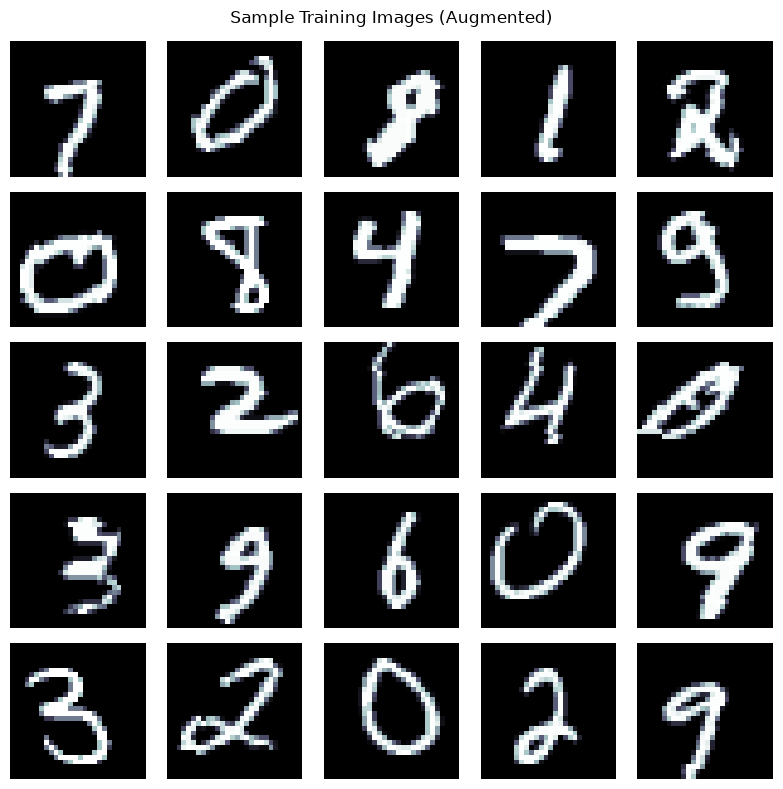

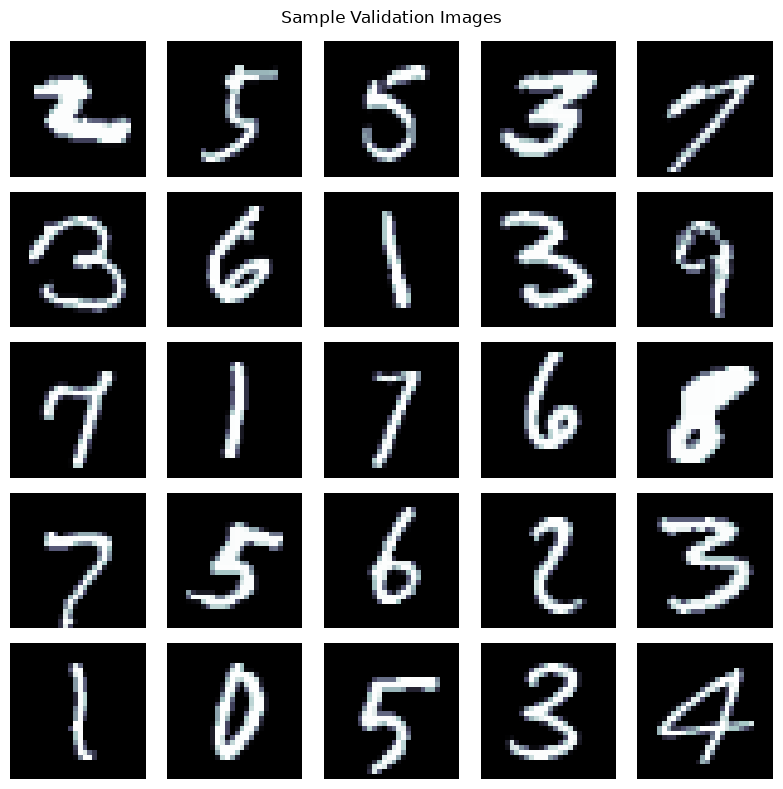

In [6]:
def plot_image_grid(images: List[torch.Tensor], title: str = None) -> None:
    '''Display a square grid of grayscale digit images.

    Args:
        images: A list of image tensors, each reshapeable to ``(28, 28)``.
        title: Optional figure title.
    '''
    n_images = len(images)
    grid_size = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(8, 8))
    if title:
        fig.suptitle(title)
    for i in range(grid_size * grid_size):
        ax = fig.add_subplot(grid_size, grid_size, i + 1)
        ax.imshow(images[i].view(28, 28).cpu().numpy(), cmap="bone")
        ax.axis("off")
    plt.tight_layout()
    plt.show()


sample_train_images = [image for image, _ in (train_data[i] for i in range(CONFIG.display_grid_size))]
plot_image_grid(sample_train_images, title="Sample Training Images (Augmented)")

sample_valid_images = [image for image, _ in (valid_data[i] for i in range(CONFIG.display_grid_size))]
plot_image_grid(sample_valid_images, title="Sample Validation Images")


## DataLoaders

Train, validation, and test dataloaders are created; only the training
loader shuffles its data, since shuffling validation/test data has no
benefit and only adds overhead.


In [7]:
def build_dataloaders(
    train_data: data.Dataset,
    valid_data: data.Dataset,
    test_data: data.Dataset,
    batch_size: int,
) -> Tuple[data.DataLoader, data.DataLoader, data.DataLoader]:
    '''Construct train, validation, and test dataloaders.

    Args:
        train_data: Training dataset.
        valid_data: Validation dataset.
        test_data: Test dataset.
        batch_size: Number of samples per batch.

    Returns:
        A tuple of ``(train_iterator, valid_iterator, test_iterator)``.
    '''
    train_iterator = data.DataLoader(train_data, shuffle=True, batch_size=batch_size)
    valid_iterator = data.DataLoader(valid_data, batch_size=batch_size)
    test_iterator = data.DataLoader(test_data, batch_size=batch_size)
    return train_iterator, valid_iterator, test_iterator


train_iterator, valid_iterator, test_iterator = build_dataloaders(
    train_data, valid_data, test_data, CONFIG.batch_size
)


## Model Architecture

A simple three-layer MLP classifies flattened 28x28 digit images into 10
classes. The model returns both the final logits **and** the last hidden
layer's activations, since those intermediate representations are reused
later for PCA/t-SNE analysis.


In [8]:
class MLP(nn.Module):
    '''A three-layer multilayer perceptron for MNIST digit classification.

    Args:
        input_dim: Flattened input dimensionality (28 * 28 for MNIST).
        hidden_dim_1: Size of the first hidden layer.
        hidden_dim_2: Size of the second hidden layer.
        output_dim: Number of output classes.
    '''

    def __init__(self, input_dim: int, hidden_dim_1: int, hidden_dim_2: int, output_dim: int):
        super().__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim_1)
        self.hidden_fc = nn.Linear(hidden_dim_1, hidden_dim_2)
        self.output_fc = nn.Linear(hidden_dim_2, output_dim)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        '''Flatten the input, pass it through the MLP, and return logits and features.

        Args:
            x: Input tensor of shape ``(batch_size, height, width)``.

        Returns:
            A tuple of ``(logits, hidden_features)`` where ``logits`` has
            shape ``(batch_size, output_dim)`` and ``hidden_features`` has
            shape ``(batch_size, hidden_dim_2)``.
        '''
        batch_size = x.shape[0]
        x = x.view(batch_size, -1)

        h_1 = F.relu(self.input_fc(x))
        h_2 = F.relu(self.hidden_fc(h_1))
        logits = self.output_fc(h_2)

        return logits, h_2


def count_parameters(model: nn.Module) -> int:
    '''Count the number of trainable parameters in a model.

    Args:
        model: The PyTorch model to inspect.

    Returns:
        The total number of trainable parameters.
    '''
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = MLP(CONFIG.input_dim, CONFIG.hidden_dim_1, CONFIG.hidden_dim_2, CONFIG.output_dim).to(device)
print(f"The model has {count_parameters(model):,} trainable parameters")
model


The model has 222,360 trainable parameters


MLP(
  (input_fc): Linear(in_features=784, out_features=250, bias=True)
  (hidden_fc): Linear(in_features=250, out_features=100, bias=True)
  (output_fc): Linear(in_features=100, out_features=10, bias=True)
)

## Model Training

The model is trained with the Adam optimizer and cross-entropy loss. After
every epoch, the model is evaluated on the validation set, and the
best-performing checkpoint (by validation loss) is saved to disk.

> **Improvement over the original script:** training/validation loss and
> accuracy for every epoch are now collected into a `history` dictionary and
> plotted afterward, making it easy to visually spot overfitting instead of
> only reading printed numbers.


In [9]:
def calculate_accuracy(y_pred: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    '''Compute top-1 classification accuracy for a batch of predictions.

    Args:
        y_pred: Model logits of shape ``(batch_size, num_classes)``.
        y: Ground-truth labels of shape ``(batch_size,)``.

    Returns:
        A scalar tensor with the batch accuracy.
    '''
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    return correct.float() / y.shape[0]


def train_one_epoch(
    model: nn.Module,
    iterator: data.DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> Tuple[float, float]:
    '''Run a single training epoch over the given dataloader.

    Args:
        model: The classifier being trained.
        iterator: Dataloader yielding ``(images, labels)`` batches.
        optimizer: Optimizer used to update model weights.
        criterion: Classification loss function.
        device: Device to run computation on.

    Returns:
        A tuple of ``(average_loss, average_accuracy)`` for the epoch.
    '''
    epoch_loss = 0.0
    epoch_acc = 0.0

    model.train()

    for x, y in tqdm(iterator, desc="Training", leave=False):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        y_pred, _ = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)


@torch.no_grad()
def evaluate(
    model: nn.Module,
    iterator: data.DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> Tuple[float, float]:
    '''Evaluate the model on a validation/test dataloader.

    Args:
        model: The classifier being evaluated.
        iterator: Dataloader yielding ``(images, labels)`` batches.
        criterion: Classification loss function.
        device: Device to run computation on.

    Returns:
        A tuple of ``(average_loss, average_accuracy)``.
    '''
    epoch_loss = 0.0
    epoch_acc = 0.0

    model.eval()

    for x, y in tqdm(iterator, desc="Evaluating", leave=False):
        x, y = x.to(device), y.to(device)

        y_pred, _ = model(x)
        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)


def epoch_time(start_time: float, end_time: float) -> Tuple[int, int]:
    '''Convert an elapsed duration into whole minutes and seconds.

    Args:
        start_time: Epoch start time (from ``time.monotonic()``).
        end_time: Epoch end time (from ``time.monotonic()``).

    Returns:
        A tuple of ``(minutes, seconds)``.
    '''
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - elapsed_mins * 60)
    return elapsed_mins, elapsed_secs


def train_model(
    model: nn.Module,
    train_iterator: data.DataLoader,
    valid_iterator: data.DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    epochs: int,
    model_save_path: str,
) -> Dict[str, List[float]]:
    '''Train the model, checkpointing the best model by validation loss.

    Args:
        model: The classifier to train.
        train_iterator: Training dataloader.
        valid_iterator: Validation dataloader.
        optimizer: Optimizer used to update model weights.
        criterion: Classification loss function.
        device: Device to run computation on.
        epochs: Number of training epochs.
        model_save_path: File path to save the best-performing checkpoint.

    Returns:
        A history dictionary with ``"train_loss"``, ``"train_acc"``,
        ``"valid_loss"``, and ``"valid_acc"`` lists, one entry per epoch.
    '''
    best_valid_loss = float("inf")
    history: Dict[str, List[float]] = {"train_loss": [], "train_acc": [], "valid_loss": [], "valid_acc": []}

    for epoch in trange(epochs):
        start_time = time.monotonic()

        train_loss, train_acc = train_one_epoch(model, train_iterator, optimizer, criterion, device)
        valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), model_save_path)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        end_time = time.monotonic()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        print(f"Epoch: {epoch + 1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s")
        print(f"\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc * 100:.2f}%")
        print(f"\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc * 100:.2f}%")

    return history


optimizer = optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss().to(device)

history = train_model(
    model, train_iterator, valid_iterator, optimizer, criterion, device, CONFIG.epochs, CONFIG.model_save_path
)


  0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/844 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch: 01 | Epoch Time: 0m 24s
	Train Loss: 0.399 | Train Acc: 87.41%
	 Val. Loss: 0.144 |  Val. Acc: 95.45%


Training:   0%|          | 0/844 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch: 09 | Epoch Time: 0m 26s
	Train Loss: 0.085 | Train Acc: 97.36%
	 Val. Loss: 0.069 |  Val. Acc: 97.87%


Training:   0%|          | 0/844 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch: 10 | Epoch Time: 0m 26s
	Train Loss: 0.076 | Train Acc: 97.60%
	 Val. Loss: 0.060 |  Val. Acc: 98.15%


## Training Curves

Plotting loss and accuracy for both training and validation sets makes it
straightforward to check for overfitting or instability across epochs.


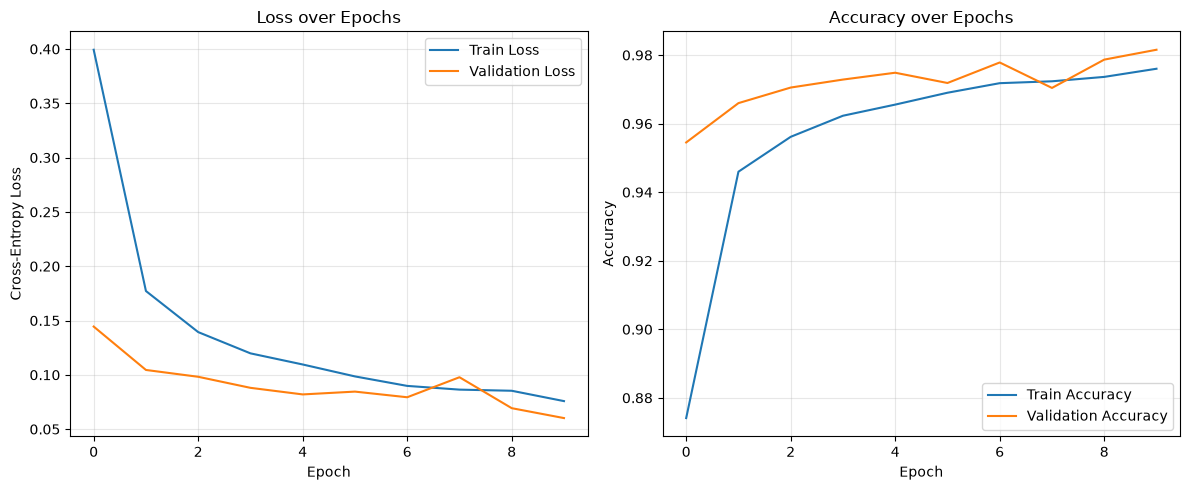

In [10]:
def plot_training_curves(history: Dict[str, List[float]]) -> None:
    '''Plot training/validation loss and accuracy curves side by side.

    Args:
        history: Dictionary with ``"train_loss"``, ``"train_acc"``,
            ``"valid_loss"``, and ``"valid_acc"`` lists.
    '''
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 5))

    ax_loss.plot(history["train_loss"], label="Train Loss")
    ax_loss.plot(history["valid_loss"], label="Validation Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Cross-Entropy Loss")
    ax_loss.set_title("Loss over Epochs")
    ax_loss.legend()
    ax_loss.grid(alpha=0.3)

    ax_acc.plot(history["train_acc"], label="Train Accuracy")
    ax_acc.plot(history["valid_acc"], label="Validation Accuracy")
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title("Accuracy over Epochs")
    ax_acc.legend()
    ax_acc.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(history)


## Evaluation

The best checkpoint (by validation loss) is reloaded and evaluated once on
the held-out test set to report a final, unbiased performance estimate.


In [11]:
model.load_state_dict(torch.load(CONFIG.model_save_path, map_location=device))

test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f"Test Loss: {test_loss:.3f} | Test Acc: {test_acc * 100:.2f}%")


C:\Users\Mehran\AppData\Local\Temp\ipykernel_9116\3093631278.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CONFIG.model_save_path, map

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Test Loss: 0.049 | Test Acc: 98.55%


## Confusion Matrix

A confusion matrix over the test set reveals which digit pairs the model
tends to confuse with one another.


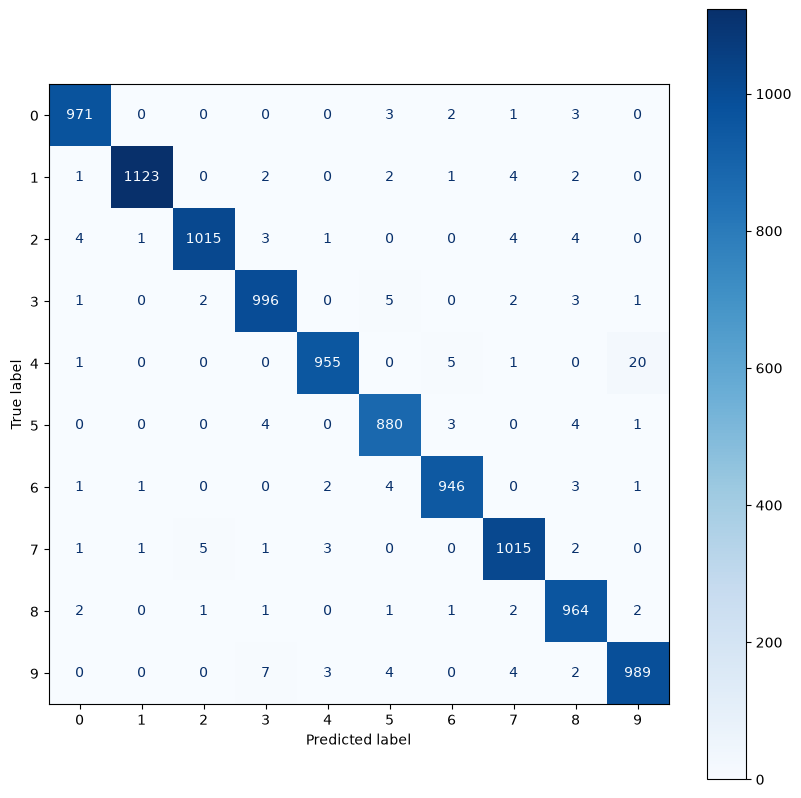

In [12]:
@torch.no_grad()
def get_predictions(
    model: nn.Module,
    iterator: data.DataLoader,
    device: torch.device,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    '''Collect model inputs, true labels, and predicted class probabilities.

    Args:
        model: The trained classifier.
        iterator: Dataloader to run inference over.
        device: Device to run inference on.

    Returns:
        A tuple of ``(images, labels, probs)`` concatenated across all batches.
    '''
    model.eval()

    all_images, all_labels, all_probs = [], [], []

    for x, y in iterator:
        x = x.to(device)
        y_pred, _ = model(x)
        y_prob = F.softmax(y_pred, dim=-1)

        all_images.append(x.cpu())
        all_labels.append(y.cpu())
        all_probs.append(y_prob.cpu())

    return torch.cat(all_images), torch.cat(all_labels), torch.cat(all_probs)


def plot_confusion_matrix(labels: torch.Tensor, pred_labels: torch.Tensor) -> None:
    '''Plot a confusion matrix comparing true and predicted digit labels.

    Args:
        labels: Ground-truth labels.
        pred_labels: Model-predicted labels.
    '''
    fig, ax = plt.subplots(figsize=(10, 10))
    cm = metrics.confusion_matrix(labels, pred_labels)
    display = metrics.ConfusionMatrixDisplay(cm, display_labels=range(10))
    display.plot(values_format="d", cmap="Blues", ax=ax)
    plt.show()


images, labels, probs = get_predictions(model, test_iterator, device)
pred_labels = torch.argmax(probs, dim=1)

plot_confusion_matrix(labels, pred_labels)


## Error Analysis: Most Confident Mistakes

Beyond aggregate accuracy, it's instructive to inspect the specific test
images the model got wrong *most confidently* — these often reveal
ambiguous handwriting or genuine model weaknesses.


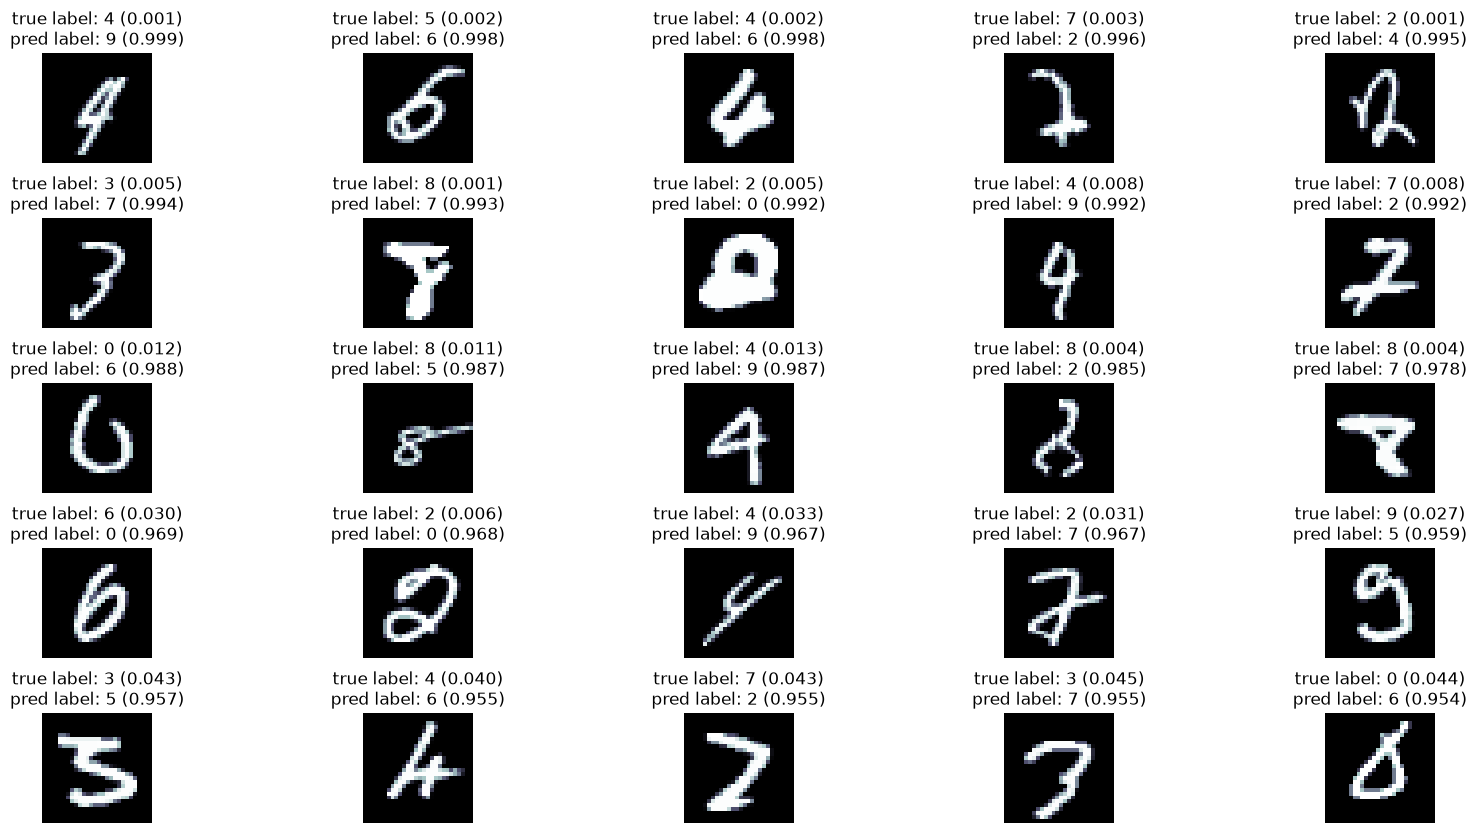

In [13]:
def find_incorrect_examples(
    images: torch.Tensor,
    labels: torch.Tensor,
    probs: torch.Tensor,
) -> List[Tuple[torch.Tensor, torch.Tensor, torch.Tensor]]:
    '''Identify misclassified examples, sorted by prediction confidence.

    Args:
        images: Test images.
        labels: Ground-truth labels.
        probs: Predicted class probabilities.

    Returns:
        A list of ``(image, true_label, probs)`` tuples for misclassified
        examples, sorted from most to least confidently wrong.
    '''
    pred_labels = torch.argmax(probs, dim=1)
    correct = torch.eq(labels, pred_labels)

    incorrect = [
        (image, label, prob)
        for image, label, prob, is_correct in zip(images, labels, probs, correct)
        if not is_correct
    ]
    incorrect.sort(key=lambda item: torch.max(item[2]).item(), reverse=True)
    return incorrect


def plot_most_incorrect(
    incorrect: List[Tuple[torch.Tensor, torch.Tensor, torch.Tensor]],
    n_images: int,
) -> None:
    '''Display the most confidently misclassified images with true/predicted labels.

    Args:
        incorrect: Sorted list of misclassified ``(image, true_label, probs)`` tuples.
        n_images: Number of examples to display.
    '''
    grid_size = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(20, 10))
    for i in range(grid_size * grid_size):
        ax = fig.add_subplot(grid_size, grid_size, i + 1)
        image, true_label, example_probs = incorrect[i]
        true_prob = example_probs[true_label]
        incorrect_prob, incorrect_label = torch.max(example_probs, dim=0)

        ax.imshow(image.view(28, 28).cpu().numpy(), cmap="bone")
        ax.set_title(
            f"true label: {true_label} ({true_prob:.3f})\n"
            f"pred label: {incorrect_label} ({incorrect_prob:.3f})"
        )
        ax.axis("off")

    fig.subplots_adjust(hspace=0.5)
    plt.show()


incorrect_examples = find_incorrect_examples(images, labels, probs)
plot_most_incorrect(incorrect_examples, CONFIG.display_grid_size)


## Representation Analysis: PCA and t-SNE

To understand what the model has learned internally, we project both the
final output logits and the second hidden layer's activations down to 2D
using PCA (fast, linear) and t-SNE (slower, non-linear but often more
visually separable), and color each point by its true digit label.

> **Note:** t-SNE is run on a fixed-size sample (`Config.tsne_sample_size`)
> rather than the full dataset, since it scales poorly with sample count.


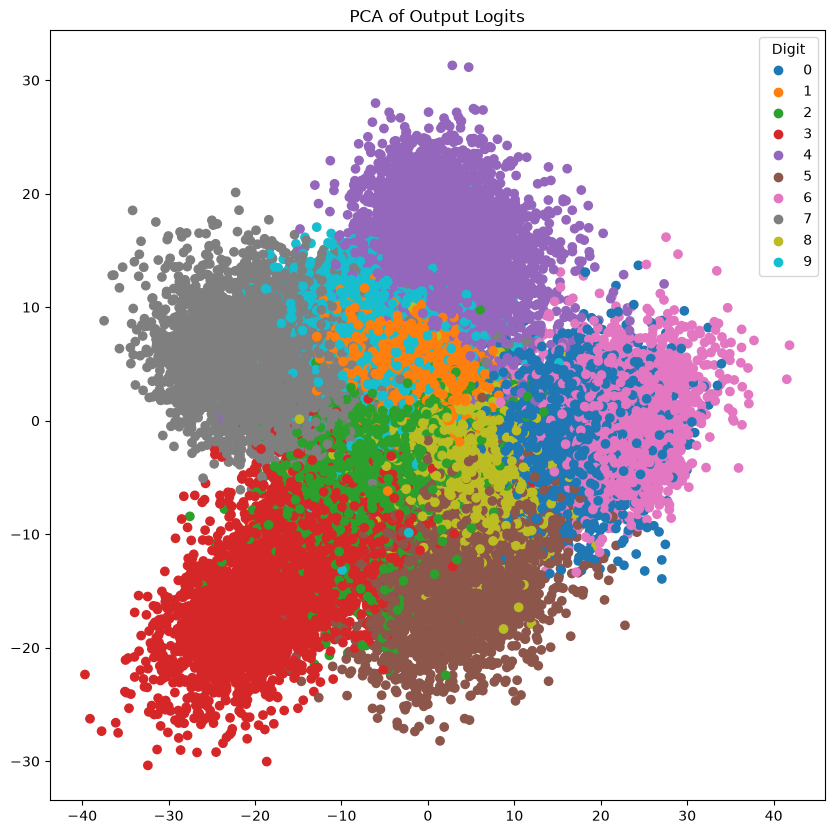

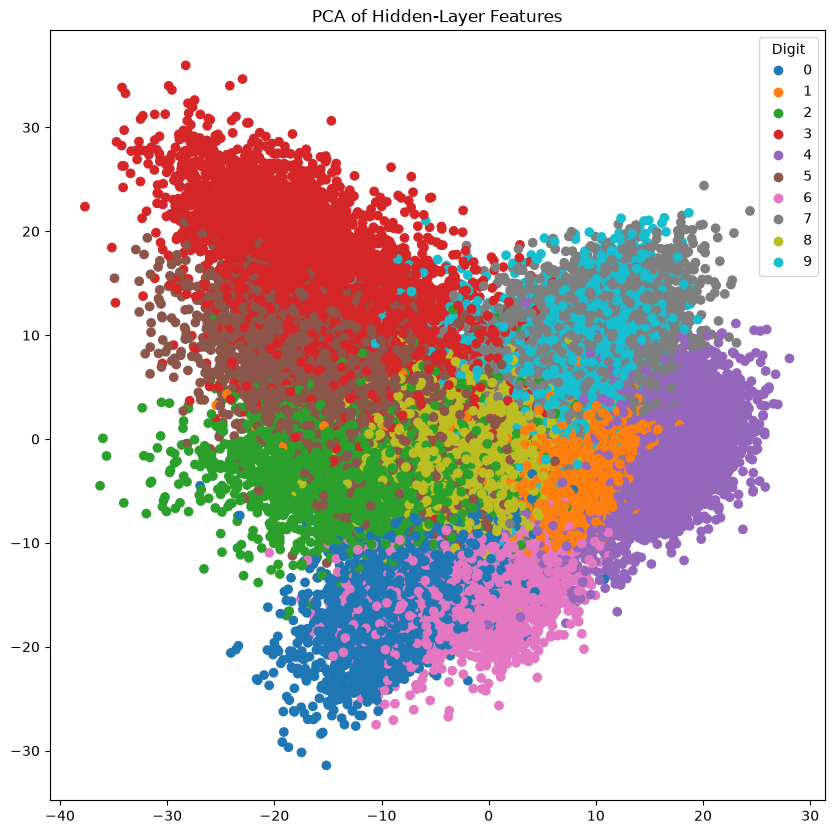

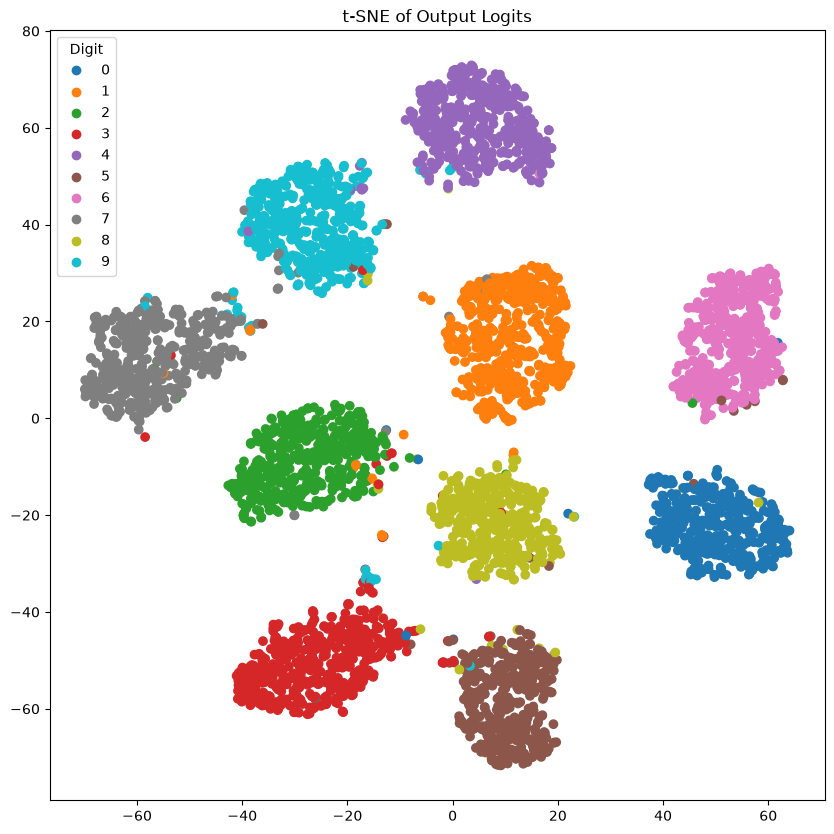

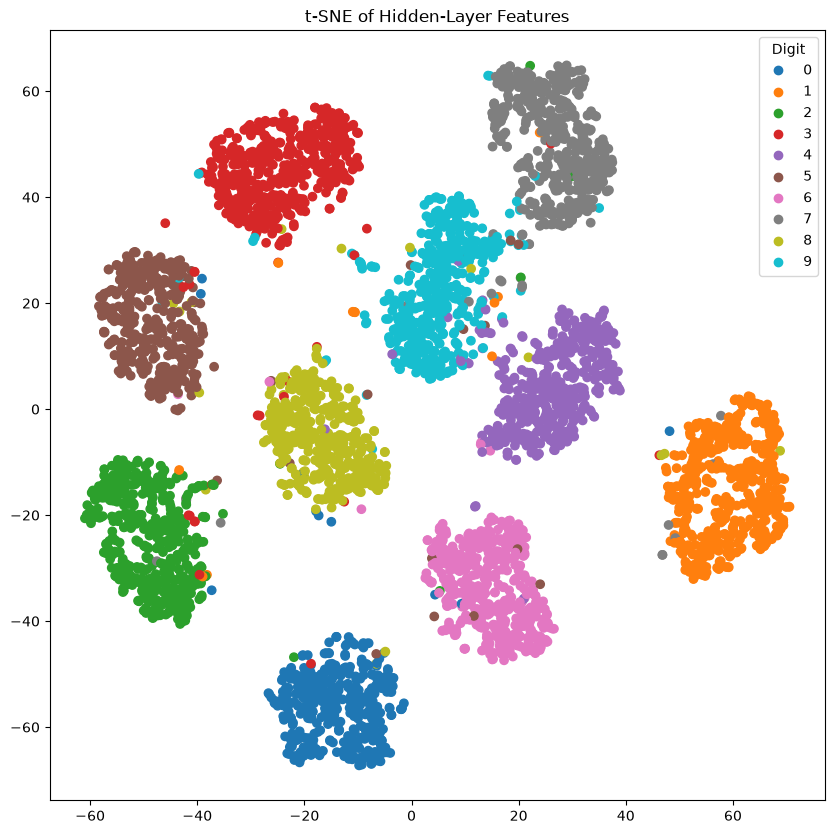

In [14]:
@torch.no_grad()
def get_representations(
    model: nn.Module,
    iterator: data.DataLoader,
    device: torch.device,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    '''Collect model output logits, hidden-layer features, and labels.

    Args:
        model: The trained classifier.
        iterator: Dataloader to run inference over.
        device: Device to run inference on.

    Returns:
        A tuple of ``(outputs, intermediates, labels)`` concatenated across
        all batches.
    '''
    model.eval()

    all_outputs, all_intermediates, all_labels = [], [], []

    for x, y in tqdm(iterator, desc="Collecting representations"):
        x = x.to(device)
        y_pred, h = model(x)

        all_outputs.append(y_pred.cpu())
        all_intermediates.append(h.cpu())
        all_labels.append(y)

    return torch.cat(all_outputs), torch.cat(all_intermediates), torch.cat(all_labels)


def get_pca(data_matrix: torch.Tensor, n_components: int = 2) -> np.ndarray:
    '''Project a data matrix to a lower dimension using PCA.

    Args:
        data_matrix: Input data of shape ``(n_samples, n_features)``.
        n_components: Target number of dimensions.

    Returns:
        The PCA-transformed data as a NumPy array.
    '''
    pca = decomposition.PCA(n_components=n_components)
    return pca.fit_transform(data_matrix)


def get_tsne(data_matrix: torch.Tensor, n_components: int = 2, n_samples: int = None) -> np.ndarray:
    '''Project a data matrix to a lower dimension using t-SNE.

    Args:
        data_matrix: Input data of shape ``(n_samples, n_features)``.
        n_components: Target number of dimensions.
        n_samples: If given, only the first ``n_samples`` rows are used.

    Returns:
        The t-SNE-transformed data as a NumPy array.
    '''
    if n_samples is not None:
        data_matrix = data_matrix[:n_samples]
    tsne = manifold.TSNE(n_components=n_components, random_state=CONFIG.seed)
    return tsne.fit_transform(data_matrix)


def plot_representations(data_2d: np.ndarray, labels: torch.Tensor, n_samples: int = None, title: str = None) -> None:
    '''Scatter-plot 2D representations colored by class label.

    Args:
        data_2d: 2D-projected data of shape ``(n_samples, 2)``.
        labels: Class labels corresponding to each row of ``data_2d``.
        n_samples: If given, only the first ``n_samples`` points are shown.
        title: Optional plot title.
    '''
    if n_samples is not None:
        data_2d = data_2d[:n_samples]
        labels = labels[:n_samples]

    fig, ax = plt.subplots(figsize=(10, 10))
    scatter = ax.scatter(data_2d[:, 0], data_2d[:, 1], c=labels, cmap="tab10")
    handles, tick_labels = scatter.legend_elements()
    ax.legend(handles=handles, labels=tick_labels, title="Digit")
    if title:
        ax.set_title(title)
    plt.show()


outputs, intermediates, train_labels = get_representations(model, train_iterator, device)

output_pca = get_pca(outputs)
plot_representations(output_pca, train_labels, title="PCA of Output Logits")

intermediate_pca = get_pca(intermediates)
plot_representations(intermediate_pca, train_labels, title="PCA of Hidden-Layer Features")

output_tsne = get_tsne(outputs, n_samples=CONFIG.tsne_sample_size)
plot_representations(output_tsne, train_labels, n_samples=CONFIG.tsne_sample_size, title="t-SNE of Output Logits")

intermediate_tsne = get_tsne(intermediates, n_samples=CONFIG.tsne_sample_size)
plot_representations(
    intermediate_tsne, train_labels, n_samples=CONFIG.tsne_sample_size, title="t-SNE of Hidden-Layer Features"
)


## Exploratory Experiment: "Imagining" a Digit

As a fun probe into the model's decision boundary, this experiment generates
pure random noise images and keeps whichever one the model classifies as a
target digit with the highest confidence. It's a crude form of
input-space search — not a real generative model — but it can reveal
interesting (and sometimes unsettling) patterns the model associates with a
class.


Searching for digit 3:   0%|          | 0/50000 [00:00<?, ?it/s]

Best image probability for digit 3: 99.91%


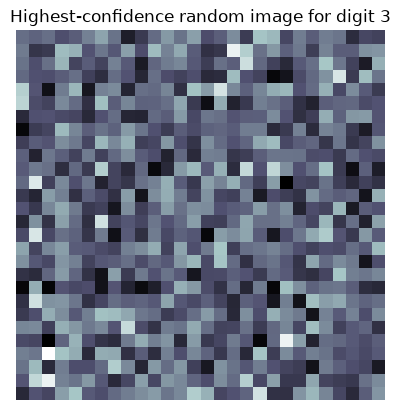

In [15]:
def imagine_digit(
    model: nn.Module,
    digit: int,
    device: torch.device,
    n_iterations: int,
) -> Tuple[torch.Tensor, torch.Tensor]:
    '''Search random noise images for the one the model most confidently labels as ``digit``.

    Args:
        model: The trained classifier.
        digit: Target digit class (0-9).
        device: Device to run inference on.
        n_iterations: Number of random images to sample and test.

    Returns:
        A tuple of ``(best_image, best_probability)``.
    '''
    model.eval()

    best_prob = 0.0
    best_image = None

    with torch.no_grad():
        for _ in trange(n_iterations, desc=f"Searching for digit {digit}"):
            x = torch.randn(32, 28, 28).to(device)
            y_pred, _ = model(x)
            preds = F.softmax(y_pred, dim=-1)

            batch_best_prob, index = torch.max(preds[:, digit], dim=0)
            if batch_best_prob > best_prob:
                best_prob = batch_best_prob
                best_image = x[index]

    return best_image, best_prob


best_image, best_prob = imagine_digit(model, CONFIG.imagine_digit, device, CONFIG.imagine_iterations)
print(f"Best image probability for digit {CONFIG.imagine_digit}: {best_prob.item() * 100:.2f}%")

plt.imshow(best_image.cpu().numpy(), cmap="bone")
plt.axis("off")
plt.title(f"Highest-confidence random image for digit {CONFIG.imagine_digit}")
plt.show()


## First-Layer Weight Visualization

Reshaping each first-layer weight vector back into a 28x28 image reveals
what pixel patterns each hidden unit responds most strongly to.


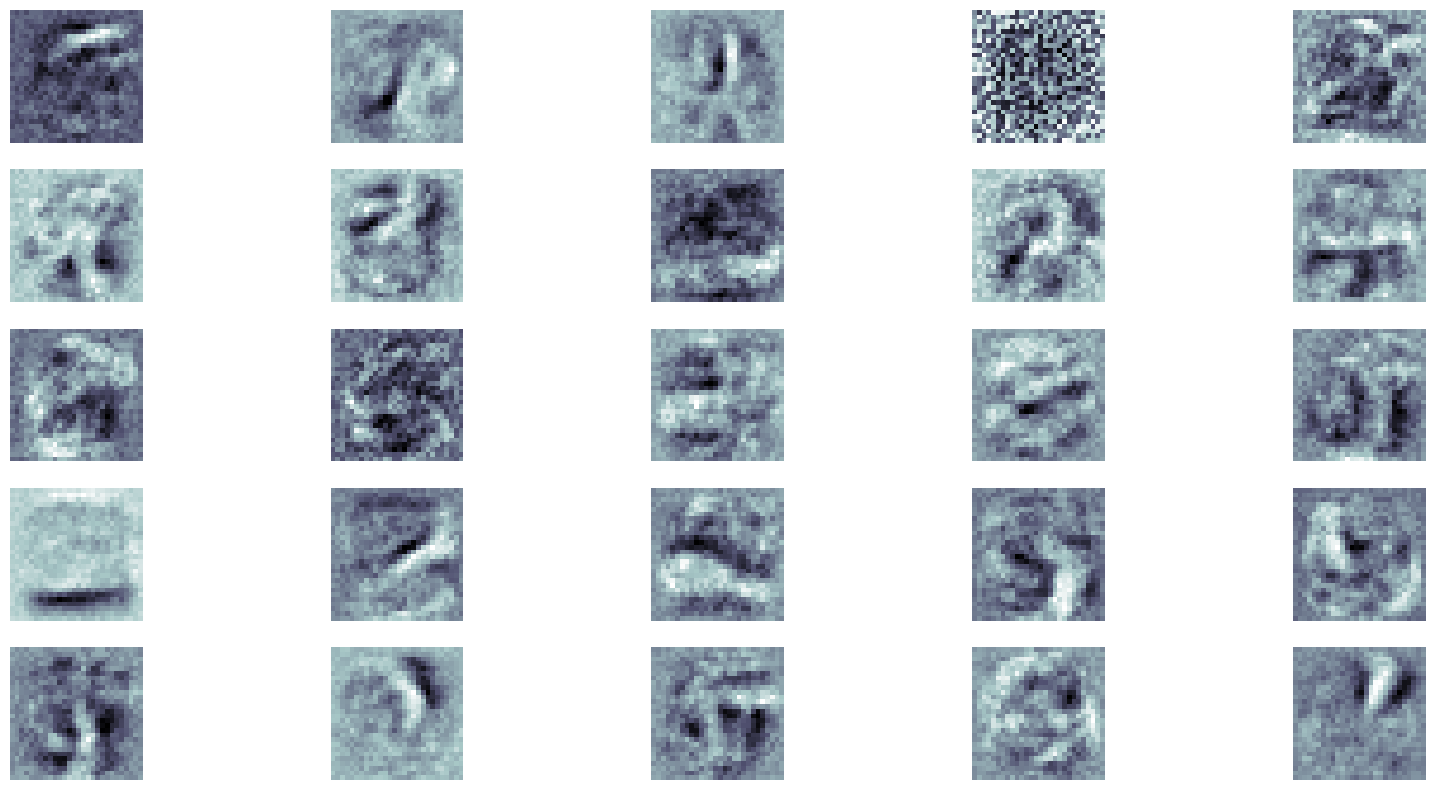

In [16]:
def plot_weight_grid(weights: torch.Tensor, n_weights: int) -> None:
    '''Display a grid of first-layer weight vectors reshaped as 28x28 images.

    Args:
        weights: Weight matrix of shape ``(n_units, 784)``.
        n_weights: Number of weight vectors to display (a perfect square).
    '''
    grid_size = int(np.sqrt(n_weights))

    fig = plt.figure(figsize=(20, 10))
    for i in range(grid_size * grid_size):
        ax = fig.add_subplot(grid_size, grid_size, i + 1)
        ax.imshow(weights[i].view(28, 28).cpu().numpy(), cmap="bone")
        ax.axis("off")
    plt.show()


first_layer_weights = model.input_fc.weight.data
plot_weight_grid(first_layer_weights, CONFIG.display_grid_size)


## Results

The MLP should reach a solid test accuracy typical of a well-tuned
fully-connected model on MNIST (commonly in the high-90s%). The confusion
matrix should show most errors concentrated among visually similar digit
pairs (e.g. 4/9, 3/5, 7/1). The PCA and t-SNE plots typically show the
second hidden layer's representations forming much tighter, more separable
clusters than the raw output logits, indicating the model has learned a
meaningful internal representation of digit identity beyond just its final
classification decision.


## Conclusion

This notebook implemented a complete MLP-based MNIST classification pipeline
with data augmentation, checkpointed training, and a thorough post-training
analysis suite covering error inspection, representation visualization, an
exploratory input-search experiment, and learned weight visualization —
going well beyond a bare-bones training loop to build genuine insight into
model behavior.


## Future Improvements

- Replace the MLP with a convolutional neural network (CNN) for a stronger
  accuracy baseline on image data.
- Add a learning-rate scheduler and early stopping based on validation loss.
- Use `torch.save`/`load` with a full training-state checkpoint (optimizer
  state, epoch number) to allow resuming interrupted training.
- Replace the brute-force random search in the "imagined digit" experiment
  with a gradient-based input optimization (activation maximization).
- Add cross-validation or repeated runs with different seeds to report
  accuracy with confidence intervals rather than a single number.
- Track experiments with TensorBoard or Weights & Biases.


## References

- LeCun, Y., Cortes, C., & Burges, C. J. C. *The MNIST Database of
  Handwritten Digits.* [http://yann.lecun.com/exdb/mnist/](http://yann.lecun.com/exdb/mnist/)
- Van der Maaten, L., & Hinton, G. (2008). *Visualizing Data using t-SNE.*
  Journal of Machine Learning Research.
- [PyTorch Documentation](https://pytorch.org/docs/stable/index.html)
- [scikit-learn Documentation](https://scikit-learn.org/stable/)
